In [1]:
!nvidia-smi
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

Tue Aug 18 19:24:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install -q kagglehub

import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
path = kagglehub.dataset_download("dhivyeshrk/diseases-and-symptoms-dataset")
print("Dataset downloaded to:", path)

import os
os.listdir(path)

Using Colab cache for faster access to the 'diseases-and-symptoms-dataset' dataset.
Dataset downloaded to: /kaggle/input/diseases-and-symptoms-dataset


['Final_Augmented_dataset_Diseases_and_Symptoms.csv']

In [5]:
import pandas as pd

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
df = pd.read_csv(os.path.join(path, csv_files[0]))
print(df.shape)
df.head()

(246945, 378)


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
import re

def normalize_symptom(value):
    if pd.isna(value):
        return None
    s = str(value).strip().lower()
    s = re.sub(r"\s+", "_", s)
    return s

label_col = df.columns[0]
SYMPTOM_COLS = [c for c in df.columns if c != label_col]

df[label_col] = df[label_col].astype(str).str.strip()

symptom_vocab = [normalize_symptom(c) for c in SYMPTOM_COLS]
df = df.rename(columns=dict(zip(SYMPTOM_COLS, symptom_vocab)))

In [7]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

X = df[symptom_vocab].to_numpy(dtype=np.float32)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[label_col])

In [8]:
from sklearn.model_selection import train_test_split

MIN_SAMPLES_PER_CLASS = 5

class_counts = pd.Series(y).value_counts()
keep_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
keep_mask = pd.Series(y).isin(keep_classes).to_numpy()

X_filtered = X[keep_mask]
y_filtered = y[keep_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

In [20]:
from scipy.sparse import csr_matrix

xgb_classes = sorted(set(y_train) | set(y_test))
old_to_new = {old: new for new, old in enumerate(xgb_classes)}
new_to_old = {new: old for old, new in old_to_new.items()}

y_train_r = np.array([old_to_new[v] for v in y_train])
y_test_r = np.array([old_to_new[v] for v in y_test])

num_classes = len(xgb_classes)
print(f"{num_classes} classes remapped to a dense 0..{num_classes-1} range")

721 classes remapped to a dense 0..720 range


In [10]:
sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_r, test_size=0.2, random_state=42, stratify=y_train_r
)
print(f"train: {X_tr.shape[0]}, val: {X_val.shape[0]}, test: {X_test.shape[0]}")

train: 157966, val: 39492, test: 49365


In [11]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(len(symptom_vocab),)),
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       193,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 721)            │        93,009 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 453,841 (1.73 MB)

 Trainable params: 452,305 (1.73 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [12]:
from sklearn.utils.class_weight import compute_class_weight

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

class_weights_arr = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_tr)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print(f"Class weights computed for {len(class_weight)} classes "
      f"(min={min(class_weight.values()):.2f}, max={max(class_weight.values()):.2f})")

Class weights computed for 721 classes (min=0.28, max=73.03)


In [21]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_r = np.argmax(y_pred_probs, axis=1)
y_pred = np.array([new_to_old[v] for v in y_pred_r])

In [23]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_probs = model.predict(X_test, verbose=0)
y_pred_r = np.argmax(y_pred_probs, axis=1)
y_pred = np.array([new_to_old[v] for v in y_pred_r])

v4_accuracy = accuracy_score(y_test, y_pred)
v3_accuracy = 0.8358
v2_accuracy = 0.8521
v1_accuracy = 0.8162
print(f"v4 (Neural Network) accuracy: {v4_accuracy:.4f}")
print(f"v3 (XGBoost) accuracy:        {v3_accuracy:.4f}")
print(f"v2 (Random Forest) accuracy:  {v2_accuracy:.4f}")
print(f"v1 (Decision Tree) accuracy:  {v1_accuracy:.4f}")
print()

present_labels = sorted(set(y_test) | set(y_pred))
present_names = [label_encoder.classes_[i] for i in present_labels]
print(classification_report(y_test, y_pred, labels=present_labels, target_names=present_names, zero_division=0))

v4 (Neural Network) accuracy: 0.8641
v3 (XGBoost) accuracy:        0.8358
v2 (Random Forest) accuracy:  0.8521
v1 (Decision Tree) accuracy:  0.8162

                                                          precision    recall  f1-score   support

                               abdominal aortic aneurysm       0.90      1.00      0.95        28
                                        abdominal hernia       0.92      0.98      0.95        81
                                         abscess of nose       0.72      0.97      0.82        58
                                     abscess of the lung       1.00      1.00      1.00         4
                                  abscess of the pharynx       0.81      0.96      0.88        68
                                    acanthosis nigricans       0.56      0.83      0.67         6
                                               acariasis       1.00      0.86      0.92         7
                                               achalasia       0.5

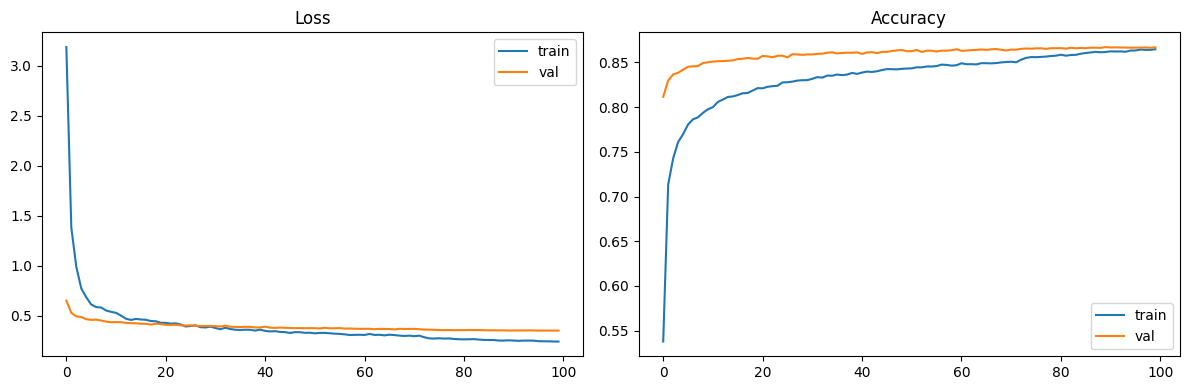

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
import json, os

os.makedirs("model_artifacts", exist_ok=True)

model.save("model_artifacts/v4_neural_network.keras")

label_classes = [label_encoder.classes_[new_to_old[i]] for i in range(num_classes)]
with open("model_artifacts/label_classes.json", "w") as f:
    json.dump(label_classes, f, indent=2)

with open("model_artifacts/symptom_vocab.json", "w") as f:
    json.dump(symptom_vocab, f, indent=2)

assert len(label_classes) == num_classes
assert model.predict(X_test, verbose=0).shape[1] == len(label_classes), (
    "predict() width mismatch — do not ship"
)

print(f"{len(label_classes)} disease classes exported")
!ls -la model_artifacts

import shutil
shutil.make_archive("v4_model_artifacts", "zip", "model_artifacts")

from google.colab import files
files.download("v4_model_artifacts.zip")

721 disease classes exported
total 5396
drwxr-xr-x 2 root root    4096 Aug 18 19:52 .
drwxr-xr-x 1 root root    4096 Aug 18 19:52 ..
-rw-r--r-- 1 root root   17367 Aug 18 19:52 label_classes.json
-rw-r--r-- 1 root root    8606 Aug 18 19:52 symptom_vocab.json
-rw-r--r-- 1 root root 5482904 Aug 18 19:52 v4_neural_network.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>